In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
import pyproj
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/drdarby/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
from datetime import timedelta
from scipy.interpolate import griddata
from tqdm.notebook import tqdm

Q1: When are submesoscale dynamics most active in the Cape Mendocino region?


H1: Elevated submesoscale activity occurs during the summer season when density and temperature gradients are strongest. This will be determined by calculating LCS over time windows of 6–12 hours and counting the number of LCS associated with submesoscale behaviors, such as fronts and eddies.

In order to answer this question, we will extract the FTLE ridges, our estimate of Lagrangian Coherent Structures (LCS), and create a timeseries of total points associated with these ridges.
Corollary: Points associated with FTLE ridges will be predominatly associated with submesoscale variability. These points will have relative vorticity or Rossby numbers ~ $O(1)$ and thus a good estimate for submesoscale behavior. This will be explored and answered with H2.

In [2]:
cutout_path = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/'
path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/'

In [3]:
ridge_points = xr.open_dataset(cutout_path+'ridge_points_repelling_bad.nc')

In [4]:
ridge_counts_attracting = []
ridge_counts_repelling = []
for i in range(0,len(ridge_points.time)):
    lon_points_attr = ridge_points.isel(time=i,lon_lat=0)['attracting_structures'].dropna('points',how='all')
    lat_points_attr = ridge_points.isel(time=i,lon_lat=1)['attracting_structures']
    lon_points_rep = ridge_points.isel(time=i,lon_lat=0)['repelling_structures'].dropna('points',how='all')
    ridge_counts_attracting.append(len(lon_points_attr))
    ridge_counts_repelling.append(len(lon_points_rep))
    lat_points_rep = ridge_points.isel(time=i,lon_lat=1)['repelling_structures'].dropna('points',how='all')

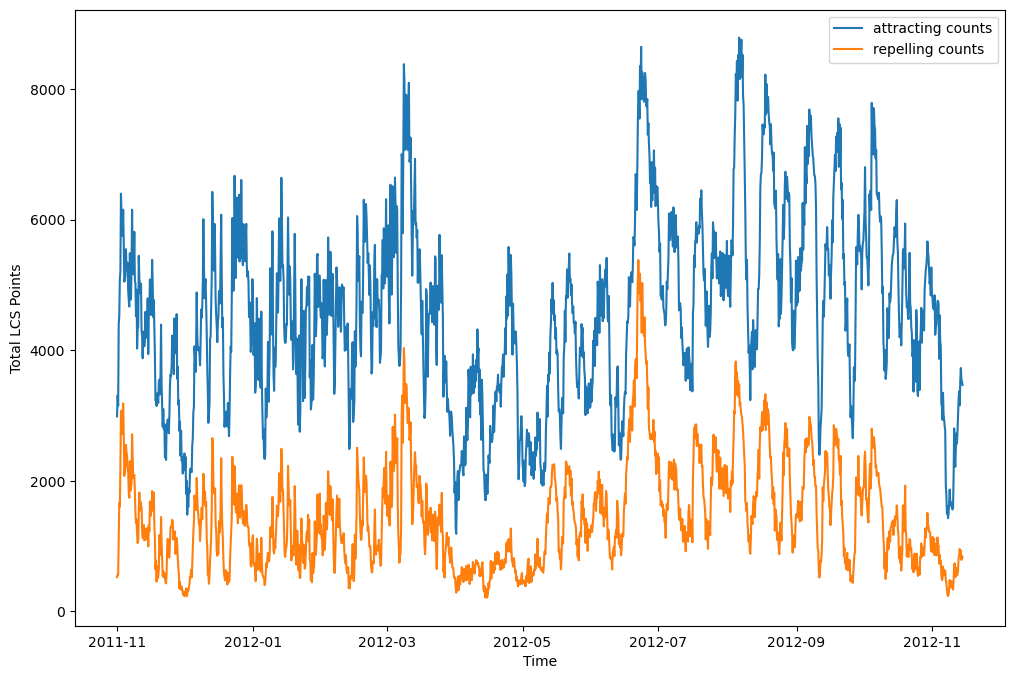

In [5]:
plt.figure(figsize=(12,8))
plt.plot(ridge_points.time,ridge_counts_attracting,label='attracting counts')
plt.plot(ridge_points.time,ridge_counts_repelling,label='repelling counts')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Total LCS Points')
plt.savefig('./counts_of_LCS.png')

In [6]:
Attracting_counts = xr.DataArray(ridge_counts_attracting, dims='time',coords=[ridge_points.time])
Repelling_counts = xr.DataArray(ridge_counts_repelling, dims='time',coords=[ridge_points.time])


In [7]:
Winter_counts_attr = Attracting_counts.sel(time=slice('2011-12','2012-02'))
Winter_counts_rep = Repelling_counts.sel(time=slice('2011-12','2012-02'))
Spring_counts_attr = Attracting_counts.sel(time=slice('2012-03','2012-05'))
Spring_counts_rep = Repelling_counts.sel(time=slice('2012-03','2012-05'))
Summer_counts_attr = Attracting_counts.sel(time=slice('2012-06','2012-08'))
Summer_counts_rep = Repelling_counts.sel(time=slice('2012-06','2012-08'))
Fall_counts_attr = Attracting_counts.sel(time=slice('2012-09','2012-11'))
Fall_counts_rep = Repelling_counts.sel(time=slice('2012-09','2012-11'))

In [8]:
print('attracting:')
print('winter', float(Winter_counts_attr.mean('time')))
print('spring', float(Spring_counts_attr.mean('time')))
print('summer',float(Summer_counts_attr.mean('time')))
print('fall',float(Fall_counts_attr.mean('time')))
print('repelling:')
print('winter', float(Winter_counts_rep.mean('time')))
print('spring', float(Spring_counts_rep.mean('time')))
print('summer',float(Summer_counts_rep.mean('time')))
print('fall',float(Fall_counts_rep.mean('time')))

attracting:
winter 4389.758241758242
spring 3860.5190217391305
summer 5397.0
fall 4883.648829431439
repelling:
winter 1182.348901098901
spring 1182.804347826087
summer 2113.3614130434785
fall 1362.7658862876253


Difference in attracting and repelling most likely due to cutoff bounds. There seems to be a clear seasonal signals, the clearest being the transition from Winter to Spring, then Spring to Summer. Is this then a function of wind stress?

In [8]:
#land_mask
X_uniform = np.arange(-660722,-271237,1804)
Y_uniform = np.arange(81172,465913,1624)
X_uniform_grid, Y_uniform_grid = np.meshgrid(X_uniform,Y_uniform)

test_proj_files, test_proj_filepaths =  tools.get_data_paths_from_binary('/media/drdarby/Elements/data/Thesis/LLC4320/','test-working/uv_regridded',file_end='nc')
test_proj_uni = xr.open_mfdataset(test_proj_filepaths)

naned_test = test_proj_uni.where(np.logical_or(test_proj_uni['u'].mean(dim='time')>0 ,test_proj_uni['u'].mean(dim='time')<0))
naned_test_no = naned_test.dropna(how='all',dim='time')#.dropna(how='all',dim='Y')
source_crs = 'epsg:3310'#3310 # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(source_crs,target_crs)
proj_in_lat, proj_in_lon = latlon_to_polar.transform(X_uniform_grid, Y_uniform_grid)

Land_mask = xr.DataArray(~np.isfinite(np.array(naned_test_no['u'].isel(time=0))),coords=[Y_uniform,X_uniform],dims=['Y','X'],name='land_binary_mask')
projection = xr.Dataset(data_vars = dict(projection=1),attrs=dict(earth_radius=6371000.0,proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs')) 
Land_mask

#test_uv_proj = xr.merge(test_uv,projection['projection'])
projection['projection'].attrs = projection.attrs
Land_mask
Land_mask=Land_mask.where(Land_mask,0)


test_uv_proj = xr.merge([naned_test_no,projection])
Land_mask=Land_mask.where(Land_mask,0).rename('land_binary_mask')
Land_mask.attrs['grid_mapping']='epsg:3310'
Land_mask.attrs['long_name']='land_binary_mask'
Land_mask.attrs['standard_name']='land_binary_mask'
Land_mask['Y'].attrs['long_name'] = 'projection_y_coordinate'
Land_mask['Y'].attrs['units'] = 'm'
Land_mask['Y'].attrs['standard_name'] = 'projection_y_coordinate'
Land_mask['X'].attrs['long_name'] = 'projection_x_coordinate'
Land_mask['X'].attrs['units'] = 'm'
Land_mask['X'].attrs['standard_name'] = 'projection_x_coordinate'
land_mask = np.array((Land_mask.where(Land_mask<1)+1)[1:,1:])
#lcs_land_nan.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/lcs_cape_mend_landmask.nc')

In [5]:
# wind_stress = xr.open_dataset(cutout_path+'tau_cape_mend.nc')
# wind_stress_cut = wind_stress.isel(k=0)
# taux_masked = wind_stress_cut['oceTAUX'][:,:-1,:-1].where(np.isfinite(land_mask))
# tauy_masked = wind_stress_cut['oceTAUY'][:,:-1,:-1].where(np.isfinite(land_mask))
path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = '/home/drdarby/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTAUX','oceTAUY']
taux_files, taux_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[-2],file_end='nc')
tauy_files, tauy_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[-1],file_end='nc')

tauxy = xr.open_mfdataset(taux_filepaths+tauy_filepaths)#.where(np.isfinite(land_mask))
tauxy

<xarray.Dataset>
Dimensions:  (time: 9119, i: 1486, j: 672)
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T23:00:00
  * i        (i) int64 0 1 2 3 4 5 6 7 ... 1479 1480 1481 1482 1483 1484 1485
  * j        (j) int64 0 1 2 3 4 5 6 7 8 ... 663 664 665 666 667 668 669 670 671
Data variables:
    oceTAUX  (time, i, j) float32 dask.array<chunksize=(1, 1486, 672), meta=np.ndarray>
    oceTAUY  (time, i, j) float32 dask.array<chunksize=(1, 1486, 672), meta=np.ndarray>

In [6]:
tauxy = tauxy.sel(i=slice(656,892), j=slice(211,426))

In [17]:
np.shape(land_mask)

(236, 215)

In [9]:
taux_masked = tauxy['oceTAUX'][:,:-1,:-1].where(np.isfinite(land_mask))

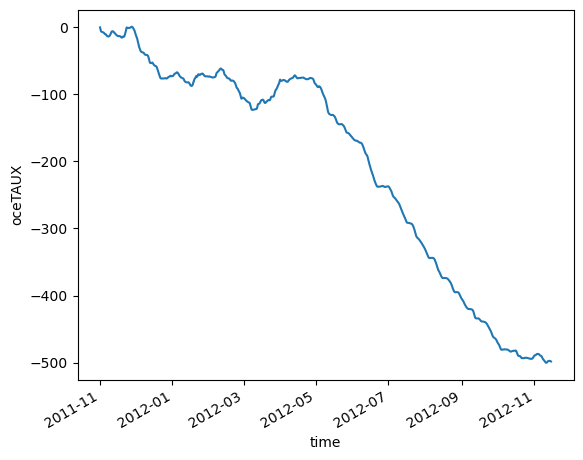

In [23]:
taux_masked.mean(dim='i',skipna=True).mean(dim='j',skipna=True).cumsum(dim='time').plot()

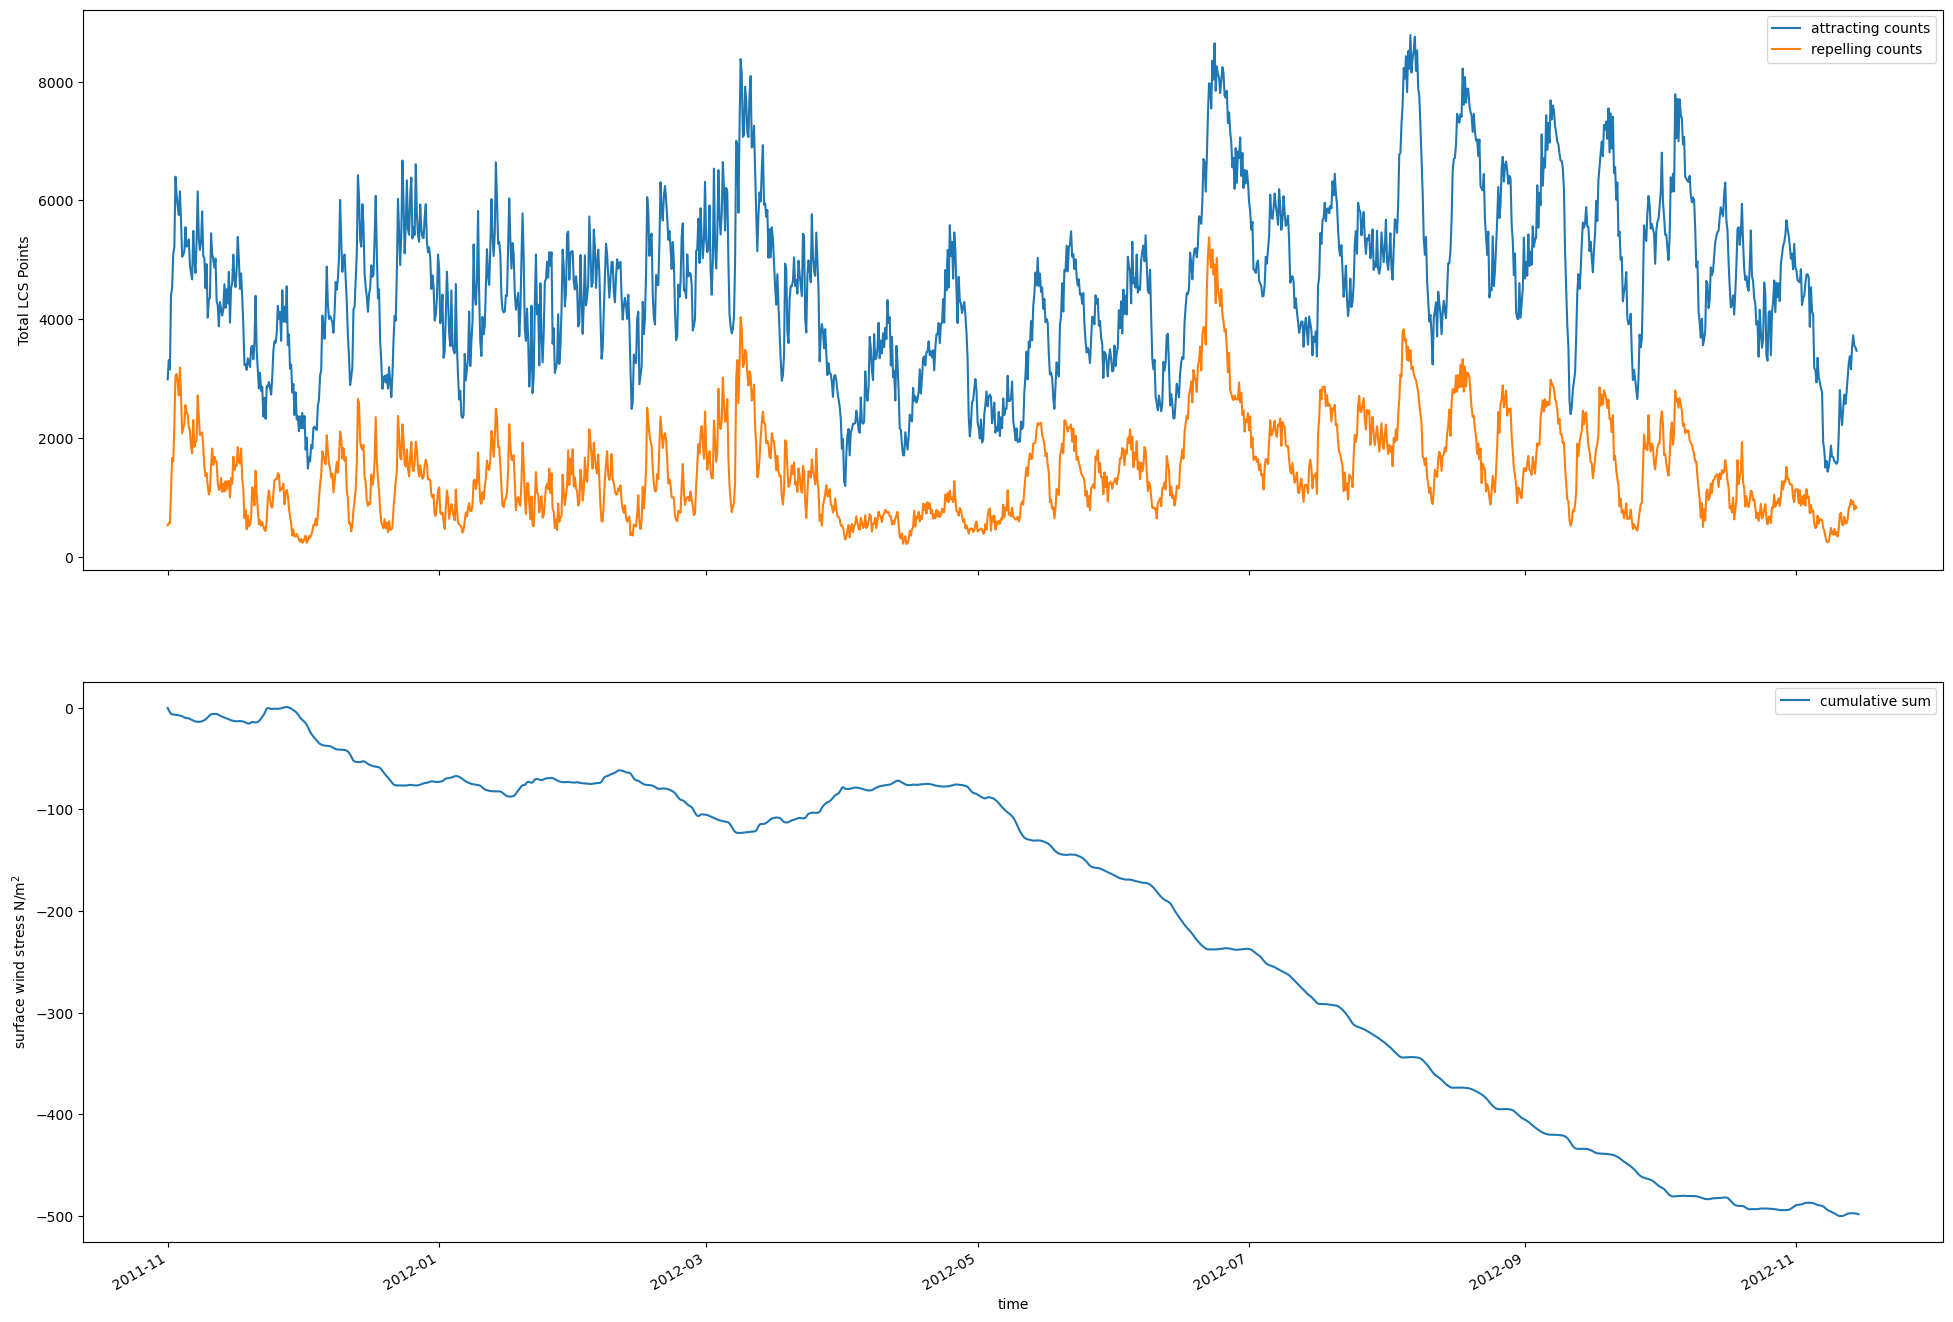

In [25]:
fig,ax = plt.subplots(ncols=1, nrows=2,figsize=(24,16),sharex=True)
ax[0].plot(ridge_points.time,ridge_counts_attracting,label='attracting counts')
ax[0].plot(ridge_points.time,ridge_counts_repelling,label='repelling counts')
ax[0].set_ylabel('Total LCS Points')
ax[0].legend()
taux_masked.mean(dim='i',skipna=True).mean(dim='j',skipna=True).cumsum(dim='time').plot(label='cumulative sum',ax=ax[1])
#tauy_masked.mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(label= 'Meridional',ax=ax[1])
plt.legend()
ax[1].set_title('')
ax[1].set_ylabel('surface wind stress N/m$^2$')
plt.savefig('./LCS_counts_and_stress.png')

Cummulative sum to define start of upwelling season. Look at before and after.
Compare to buoy

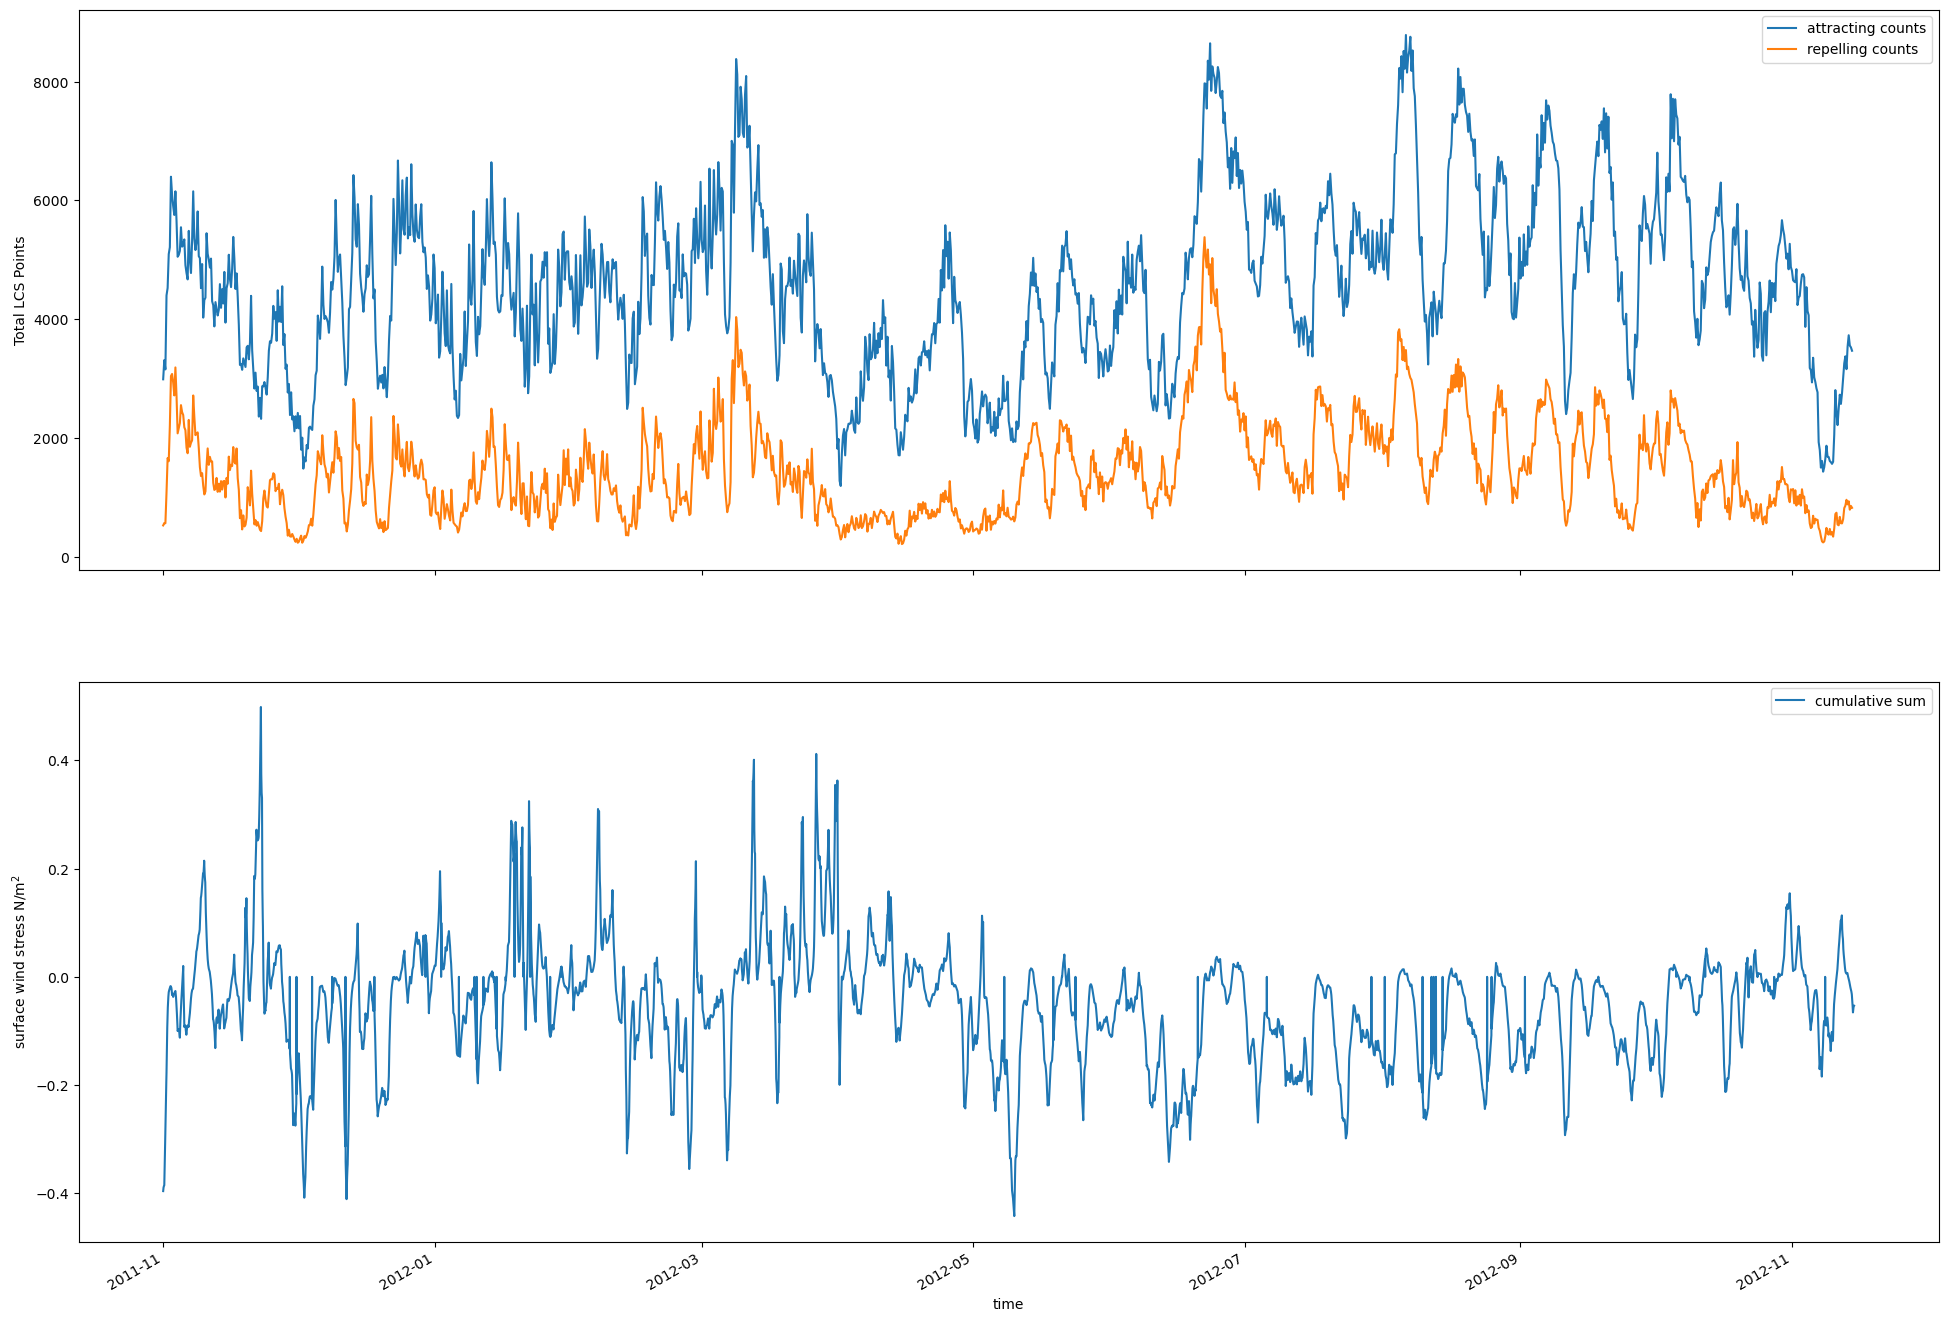

In [26]:
fig,ax = plt.subplots(ncols=1, nrows=2,figsize=(24,16),sharex=True)
ax[0].plot(ridge_points.time,ridge_counts_attracting,label='attracting counts')
ax[0].plot(ridge_points.time,ridge_counts_repelling,label='repelling counts')
ax[0].set_ylabel('Total LCS Points')
ax[0].legend()
taux_masked.mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(label='cumulative sum',ax=ax[1])
#tauy_masked.mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(label= 'Meridional',ax=ax[1])
plt.legend()
ax[1].set_title('')
ax[1].set_ylabel('surface wind stress N/m$^2$')
plt.savefig('./LCS_counts_and_stress.png')

LCS counts have a dependence on season with the 

### selecting values of vorticity, divergence, and strain at LCS attracting and repelling points

In [15]:

strain_files, strain_filepaths = tools.get_data_paths_from_binary(cutout_path,'Strain',file_end='nc')
strain = xr.open_mfdataset(strain_filepaths)
vort_div = xr.open_dataset(cutout_path+'vorticity_divergence.nc')

In [8]:
grid_path = '/home/drdarby/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)

In [23]:
np.array(vort_div.i)[-1]
#vort_div.j

891

In [45]:
grid = grid.sel(k=0,i=slice(np.array(vort_div.i)[0],np.array(vort_div.i)[-1]),j=slice(np.array(vort_div.j)[0],np.array(vort_div.j)[-1]))

In [32]:
strain
ridge_points.time

<xarray.Dataset>
Dimensions:                (points: 8784, lon_lat: 2, time: 1519)
Coordinates:
  * points                 (points) int64 0 1 2 3 4 ... 8779 8780 8781 8782 8783
  * lon_lat                (lon_lat) object 'lon' 'lat'
  * time                   (time) datetime64[ns] 2011-11-01 ... 2012-11-14T12...
Data variables:
    attracting_structures  (time, points, lon_lat) float64 ...
    repelling_structures   (time, points, lon_lat) float64 ...

In [46]:
lon = grid.XC
lat = grid.YC
Lon, Lat = lon,lat
points = np.column_stack([np.ravel(Lon), np.ravel(Lat)])

<xarray.DataArray 'YC' (i: 1486)>
array([28.002901, 28.019814, 28.036726, ..., 49.962532, 49.97516 , 49.98778 ],
      dtype=float32)
Coordinates:
  * i        (i) int64 0 1 2 3 4 5 6 7 ... 1479 1480 1481 1482 1483 1484 1485
    j        int64 0

In [40]:
len(points)
len(np.array(vort_div['vorticity'].isel(time=i)).ravel())

50740

In [16]:
vort_div = vort_div.sel(time=ridge_points.time)
strain = strain.sel(time=ridge_points.time)

In [47]:
for i in tqdm(range(0,len(ridge_points.time))):

        time = [np.array(vort_div.time)[i]]
        lon_points_attr = ridge_points.isel(time=i,lon_lat=0)['attracting_structures'].dropna('points',how='all')
        lat_points_attr = ridge_points.isel(time=i,lon_lat=1)['attracting_structures'].dropna('points',how='all')
        lon_points_rep = ridge_points.isel(time=i,lon_lat=0)['repelling_structures'].dropna('points',how='all')
        lat_points_rep = ridge_points.isel(time=i,lon_lat=1)['repelling_structures'].dropna('points',how='all')

    
        sampled_transect_vort_attr = griddata(points, np.array(vort_div['vorticity'].isel(time=i)).ravel(), (lon_points_attr, lat_points_attr))
        sampled_transect_div_attr = griddata(points, np.array(vort_div['divergence'].isel(time=i)).ravel(), (lon_points_attr, lat_points_attr))
        sampled_transect_strain_attr = griddata(points, np.array(strain['strain_rate'].isel(time=i)).ravel(), (lon_points_attr, lat_points_attr))

        sampled_transect_vort_rep = griddata(points, np.array(vort_div['vorticity'].isel(time=i)).ravel(), (lon_points_rep, lat_points_rep))
        sampled_transect_div_rep = griddata(points, np.array(vort_div['divergence'].isel(time=i)).ravel(), (lon_points_rep, lat_points_rep))
        sampled_transect_strain_rep = griddata(points, np.array(strain['strain_rate'].isel(time=i)).ravel(), (lon_points_rep, lat_points_rep))
    
        sampled_transect_vort_attr = np.reshape(sampled_transect_vort_attr, (1,len(lon_points_attr)))
        sampled_transect_div_attr = np.reshape(sampled_transect_div_attr, (1,len(lon_points_attr)))
        sampled_transect_strain_attr = np.reshape(sampled_transect_strain_attr, (1,len(lon_points_attr)))

        sampled_transect_vort_rep = np.reshape(sampled_transect_vort_rep, (1,len(lon_points_rep)))
        sampled_transect_div_rep = np.reshape(sampled_transect_div_rep, (1,len(lon_points_rep)))
        sampled_transect_strain_rep = np.reshape(sampled_transect_strain_rep, (1,len(lon_points_rep)))
    
        x_attr=np.arange(len(lon_points_attr))
        x_rep=np.arange(len(lon_points_rep))
    
        vort_lcs_attr = xr.DataArray(sampled_transect_vort_attr ,coords=[time,x_attr],dims=['time','points'],name='vort_lcs_attr')
        div_lcs_attr = xr.DataArray(sampled_transect_div_attr,coords=[time,x_attr],dims=['time','points'],name='div_lcs_attr')
        strain_lcs_attr = xr.DataArray(sampled_transect_strain_attr,coords=[time,x_attr],dims=['time','points'],name='strain_lcs_attr')

        vort_lcs_rep = xr.DataArray(sampled_transect_vort_rep ,coords=[time,x_rep],dims=['time','points'],name='vort_lcs_rep')
        div_lcs_rep = xr.DataArray(sampled_transect_div_rep,coords=[time,x_rep],dims=['time','points'],name='div_lcs_rep')
        strain_lcs_rep = xr.DataArray(sampled_transect_strain_rep,coords=[time,x_rep],dims=['time','points'],name='strain_lcs_rep')
    
        vort_lcs_rep.to_netcdf(cutout_path+'vort_lcs/vort_lcs_rep'+str(i).zfill(4)+'.nc')
        div_lcs_rep.to_netcdf(cutout_path+'div_lcs/div_lcs_rep'+str(i).zfill(4)+'.nc')
        strain_lcs_rep.to_netcdf(cutout_path+'strain_lcs/strain_lcs_rep'+str(i).zfill(4)+'.nc')

        vort_lcs_attr.to_netcdf(cutout_path+'vort_lcs/vort_lcs_attr'+str(i).zfill(4)+'.nc')
        div_lcs_attr.to_netcdf(cutout_path+'div_lcs/div_lcs_attr'+str(i).zfill(4)+'.nc')
        strain_lcs_attr.to_netcdf(cutout_path+'strain_lcs/strain_lcs_attr'+str(i).zfill(4)+'.nc')

  0%|          | 0/1519 [00:00<?, ?it/s]

In [10]:
vort_lcs_files, vort_lcs_filepaths = tools.get_data_paths_from_binary(cutout_path,'vort_lcs',file_end='nc')
div_lcs_files, div_lcs_filepaths = tools.get_data_paths_from_binary(cutout_path,'div_lcs',file_end='nc')
strain_lcs_files, strain_lcs_filepaths = tools.get_data_paths_from_binary(cutout_path,'strain_lcs',file_end='nc')


In [11]:
vort_lcs = xr.open_mfdataset(vort_lcs_filepaths)

In [12]:
div_lcs = xr.open_mfdataset(div_lcs_filepaths)

In [13]:
strain_lcs = xr.open_mfdataset(strain_lcs_filepaths)

### Average vorticity, divergence, and strain at LCS points

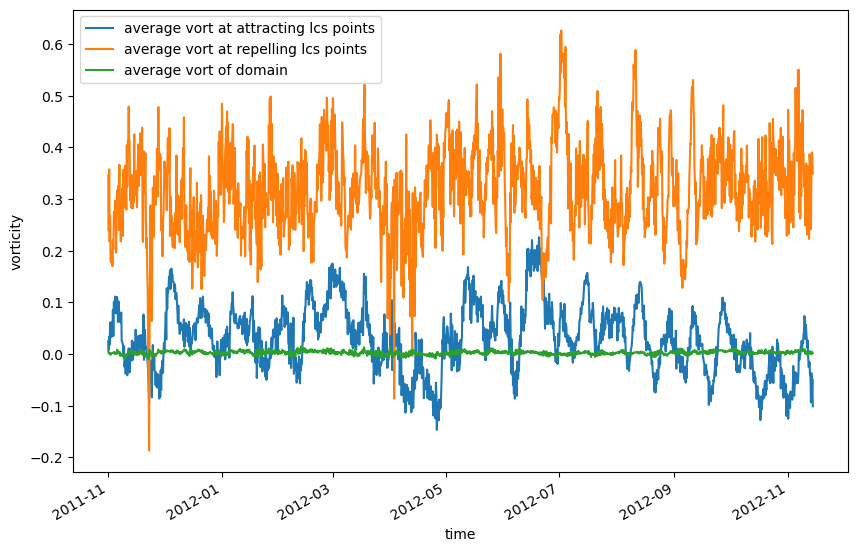

In [17]:
plt.figure(figsize=(10,6))
vort_lcs['vort_lcs_attr'].mean(dim='points',skipna=True).plot(label='average vort at attracting lcs points')
vort_lcs['vort_lcs_rep'].mean(dim='points',skipna=True).plot(label='average vort at repelling lcs points')

vort_div['vorticity'].mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(label='average vort of domain')
plt.legend()

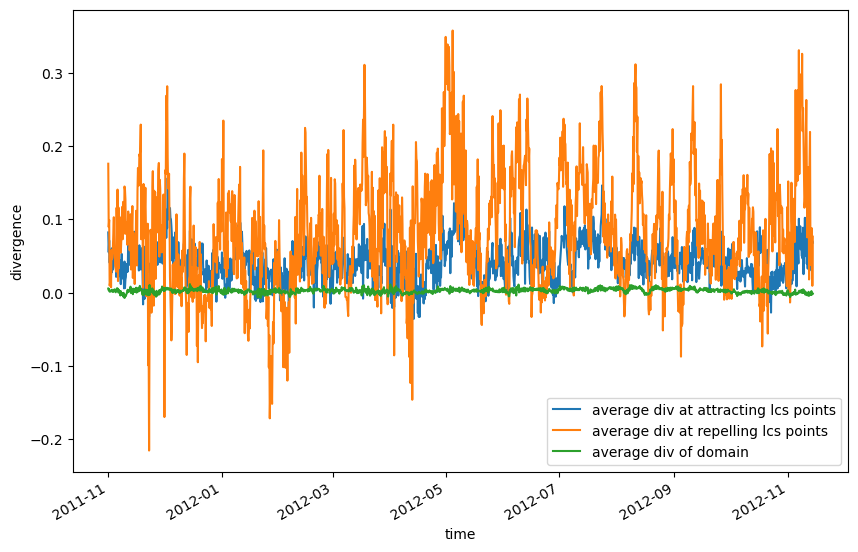

In [18]:
plt.figure(figsize=(10,6))
div_lcs['div_lcs_attr'].mean(dim='points',skipna=True).plot(label='average div at attracting lcs points')
div_lcs['div_lcs_rep'].mean(dim='points',skipna=True).plot(label='average div at repelling lcs points')

vort_div['divergence'].mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(label='average div of domain')
plt.legend()

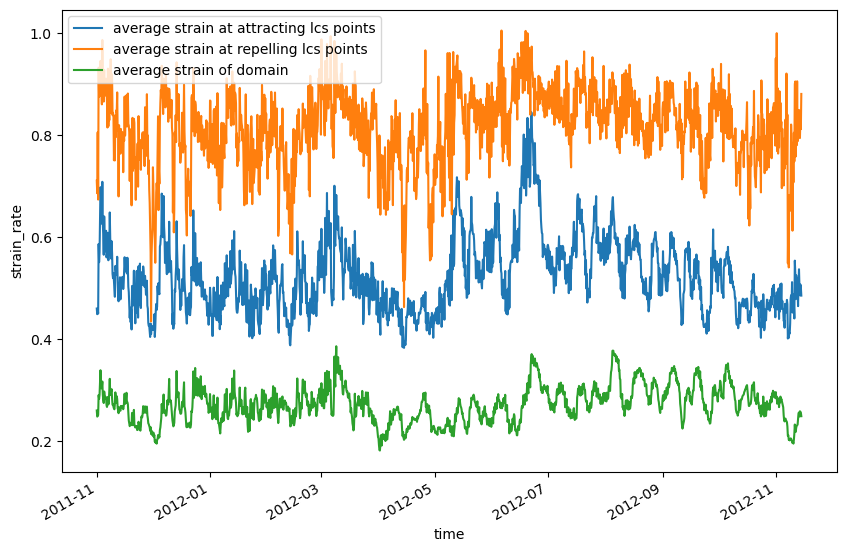

In [20]:
plt.figure(figsize=(10,6))
strain_lcs['strain_lcs_attr'].mean(dim='points',skipna=True).plot(label='average strain at attracting lcs points')
strain_lcs['strain_lcs_rep'].mean(dim='points',skipna=True).plot(label='average strain at repelling lcs points')

strain['strain_rate'].mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(label='average strain of domain')
plt.legend()

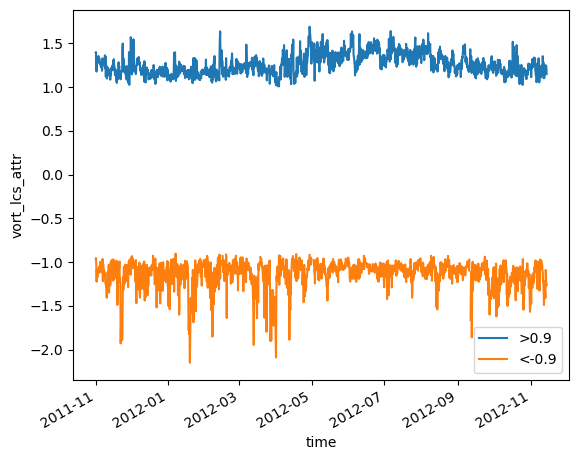

In [46]:
vort_lcs['vort_lcs_attr'].where(vort_lcs['vort_lcs_attr']>.9).mean(dim='points',skipna=True).plot(x='time',label='>0.9')
vort_lcs['vort_lcs_attr'].where(vort_lcs['vort_lcs_attr']<-.9).mean(dim='points',skipna=True).plot(x='time',label='<-0.9')
plt.legend()

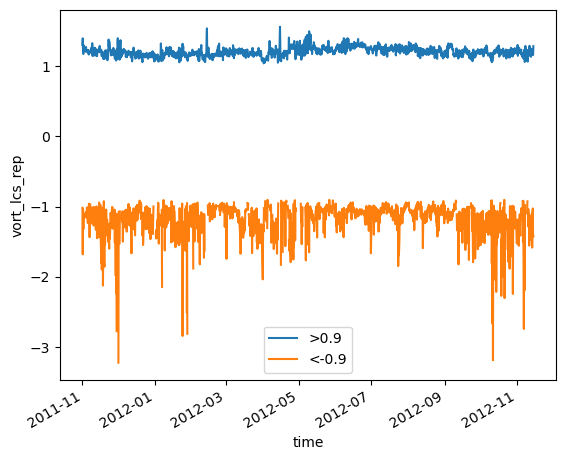

In [47]:
vort_lcs['vort_lcs_rep'].where(vort_lcs['vort_lcs_rep']>.9).mean(dim='points',skipna=True).plot(x='time',label='>0.9')
vort_lcs['vort_lcs_rep'].where(vort_lcs['vort_lcs_rep']<-.9).mean(dim='points',skipna=True).plot(x='time',label='<-0.9')
plt.legend()

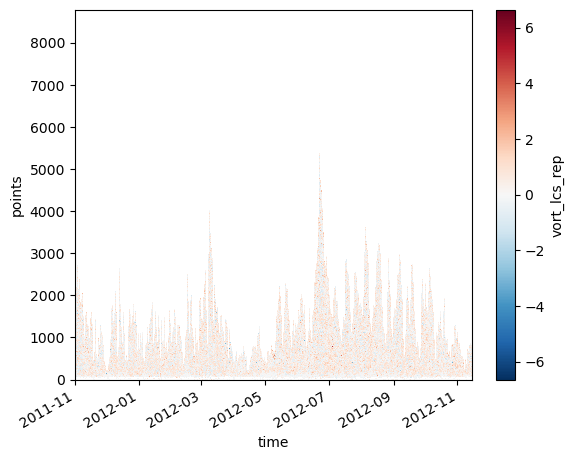

In [25]:
vort_lcs['vort_lcs_rep'].plot(x='time')

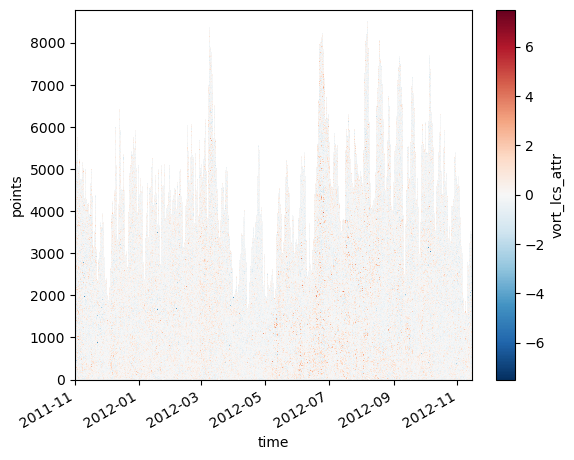

In [33]:
vort_lcs['vort_lcs_attr'].plot(x='time')

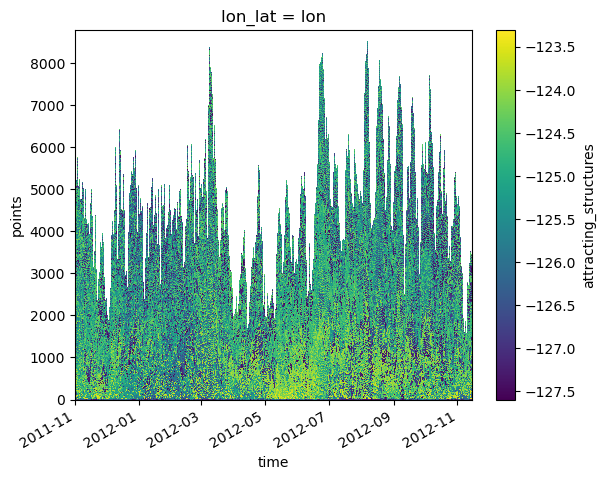

In [42]:
ridge_points.isel(lon_lat=0)['attracting_structures'].plot(x='time')


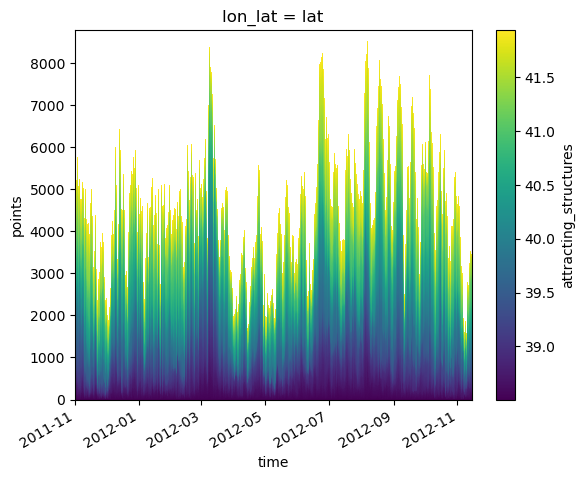

In [43]:
ridge_points.isel(lon_lat=1)['attracting_structures'].plot(x='time')

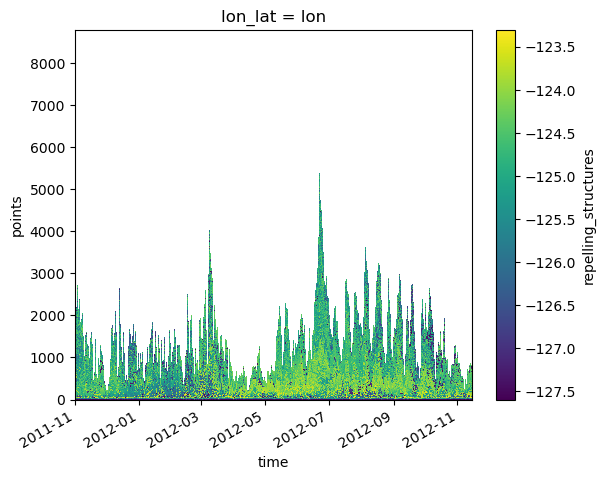

In [44]:
ridge_points.isel(lon_lat=0)['repelling_structures'].plot(x='time')


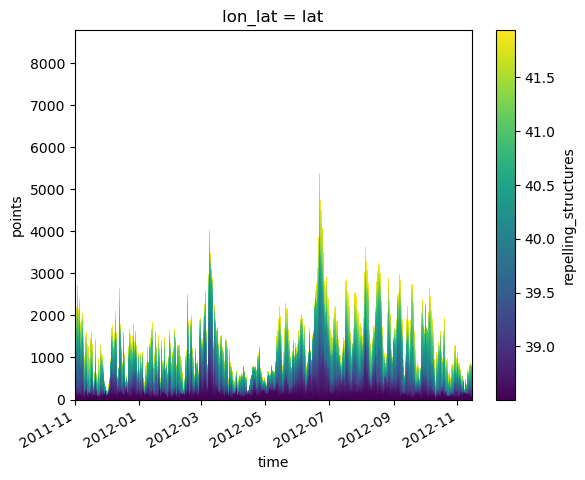

In [45]:
ridge_points.isel(lon_lat=1)['repelling_structures'].plot(x='time')


In [ ]:
#distributions, properties of LCSs